In [17]:
import sys
import os
import time
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from torchsummary import summary

sys.path.append('..')

# Project modules
from src.utility.config import BASELINE_MODEL_PATH, QUANTIZED_MODELS
from src.utility.utils import get_data_loaders
from src.model import CNN

# --- Configuration ---
# Force CPU for fair latency comparison (Float32 CPU vs INT8 CPU)
EVAL_DEVICE = torch.device('cpu') 
BATCH_SIZE = 32
MODELS_TO_EVALUATE = ["Baseline", "Affine", "Symmetric", "PoT"]

sns.set_theme(style="whitegrid")
print(f"Evaluation Configured on Device: {EVAL_DEVICE}")

Evaluation Configured on Device: cpu


In [18]:
def load_model(model_name, num_classes):
    """
    Unified loader for Baseline (StateDict) and Quantized (TorchScript).
    """
    if model_name == "Baseline":
        if not os.path.exists(BASELINE_MODEL_PATH):
            print(f"❌ Baseline not found at {BASELINE_MODEL_PATH}")
            return None
        model = CNN(num_classes=num_classes)
        model.load_state_dict(torch.load(BASELINE_MODEL_PATH, map_location=EVAL_DEVICE))
        model.eval()
        return model.to(EVAL_DEVICE)
    else:
        path = os.path.join(QUANTIZED_MODELS, f"model_{model_name}_PTQ.pt")
        if not os.path.exists(path):
            print(f"⚠️ Quantized model not found: {path}")
            return None
        # Load TorchScript model
        model = torch.jit.load(path, map_location=EVAL_DEVICE)
        model.eval()
        return model

def verify_quantization(model, model_name):
    """
    Scientifically verifies quantization by inspecting the full graph recursively.
    """
    print(f"\n🔍 Verifying Model: {model_name}")
    
    # 1. Check Baseline
    if model_name == "Baseline":
        try:
            first_param = next(model.parameters())
            print(f"   Type: Standard nn.Module")
            print(f"   Weight Dtype: {first_param.dtype}")
        except:
             print("   Type: Standard nn.Module (Empty or Scripted)")
        return

    # 2. Check Quantized (TorchScript)
    if isinstance(model, torch.jit.ScriptModule):
        model_str = str(model)
        graph_str = str(model.graph)
        
        # A) Check for Class/Layer Names in the structure
        quant_keywords = ["Quantized", "quantized", "QFunctional", "Quantize", "DeQuantize"]
        found_keywords = [k for k in quant_keywords if k in model_str]
        
        # B) Check for Low-Level Ops in the Computation Graph
        quant_ops_to_check = [
            "quantized::conv2d", 
            "quantized::linear", 
            "quantized::add", 
            "quantized::mul", 
            "quantized::cat"
        ]
        found_ops = [op for op in quant_ops_to_check if op in graph_str]
        
        if found_keywords or found_ops:
            print(f"   Status: ✅ Verified Quantized Structure")
            # Optional: Print details if needed, but keeping it clean is usually better
        else:
            print("   Status: ❌ Warning - Could not confirm quantization (Check print(model))")
            print("   Note: If Latency is ~2.5ms (vs 5.7ms Baseline), it IS quantized.")

In [19]:
def evaluate_model_comprehensive(model, loader, device):
    """
    Runs inference and calculates:
    - Accuracy, Precision, Recall, F1 (Weighted)
    - Latency (ms/img), Throughput (img/sec)
    """
    model.eval()
    model.to(device)
    
    all_preds = []
    all_targets = []
    total_samples = 0
    
    # --- 1. Warm-up (Crucial for accurate CPU timing) ---
    warmup_batches = 5
    with torch.no_grad():
        for i, (data, _) in enumerate(loader):
            if i >= warmup_batches: break
            data = data.to(device)
            _ = model(data)
            
    print("   (Warm-up complete, starting measurement...)")

    # --- 2. Inference Loop & Timing ---
    start_time = time.time()
    
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            # Targets stay on CPU to save transfer time
            
            output = model(data)
            preds = output.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(target.numpy())
            total_samples += len(data)
            
    end_time = time.time()
    
    # --- 3. Calculate Metrics ---
    duration_sec = end_time - start_time
    latency_ms = (duration_sec / total_samples) * 1000
    throughput = total_samples / duration_sec
    
    # Sklearn metrics (Weighted average handles class imbalance)
    accuracy = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average='weighted', zero_division=0
    )
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Latency (ms)": latency_ms,
        "Throughput (img/s)": throughput,
        "Total Time (s)": duration_sec,
        "Predictions": all_preds,
        "Targets": all_targets
    }

In [20]:
def _check_power_of_two(scales):
    """
    Scientific check: Returns True if ALL scales are perfect powers of two (2^k).
    Formula: If log2(scale) is an integer, then scale is a power of two.
    """
    # Calculate log2 of scales
    log_scales = torch.log2(scales)
    # Check deviation from nearest integer
    # We use a small epsilon (1e-5) to handle floating point rounding errors
    is_pot = torch.all(torch.abs(log_scales - torch.round(log_scales)) < 1e-5)
    return is_pot

def _print_stats(tensor: torch.Tensor, is_quantized: bool):
    """
    Prints shape, dtype, and intelligently detects the quantization method 
    based on Scheme (Granularity) and Zero Points.
    """
    print(f"   Shape: {tensor.shape}")
    print(f"   Dtype: {tensor.dtype}")

    if not is_quantized:
        print(f"   Values: {tensor.detach().flatten()[:5].tolist()}")
        return

    # Quantized Specifics
    print(f"   Scheme: {tensor.qscheme()}")
    print(f"   Raw Int8: {tensor.int_repr().flatten()[:5].tolist()}")

    # --- 1. Per-Channel Detection (Vectors) ---
    if tensor.qscheme() == torch.per_channel_affine:
        zps = tensor.q_per_channel_zero_points()
        scales = tensor.q_per_channel_scales()
        
        print(f"   Zero Points (First 5): {zps[:5].tolist()}")
        print(f"   Scales (First 5): {scales[:5].tolist()}")
        
        # Check properties
        is_zp_zero = torch.all(zps == 0)
        is_pot = _check_power_of_two(scales)
        
        if is_zp_zero and is_pot:
            print("   -> Method Detected: ✅ Power-of-Two (PoT)")
            print("      (Fingerprint: Per-Channel, ZP=0, Scales=2^k)")
            
        elif not is_zp_zero:
            # If it is Per-Channel but has Zero Points, it must be the Seminar Symmetric
            print("   -> Method Detected: ✅ Symmetric (Seminar Formula)")
            print("      (Fingerprint: Per-Channel, Non-Zero ZP to fit -127 range)")
            
        else:
            print("   -> Method Detected: ✅ Symmetric (Standard)")
            print("      (Fingerprint: Per-Channel, ZP=0, Linear Scales)")

    # --- 2. Per-Tensor Detection (Scalars) ---
    elif tensor.qscheme() == torch.per_tensor_affine:
        zp = tensor.q_zero_point()
        scale = tensor.q_scale()
        print(f"   Zero Point: {zp}")
        print(f"   Scale: {scale}")
        
        # In your experiment, Per-Tensor was exclusively used for Affine
        print("   -> Method Detected: ✅ Affine (Standard)")
        print("      (Fingerprint: Per-Tensor, Global Scale)")

def inspect_first_layer_weights(model: nn.Module, model_name: str):
    """
    Inspects 'conv1' weights for both Float32 and Quantized models.
    """
    print(f"\n🔬 Inspecting: {model_name}")

    # 1. Guard Clause: Check if layer exists
    if not hasattr(model, 'conv1'):
        print("   Error: 'conv1' layer not found.")
        return

    layer = model.conv1

    try:
        # 2. Check for Quantized Packed Parameters (TorchScript)
        if hasattr(layer, '_packed_params'):
            weight, _ = layer._packed_params.unpack()
            _print_stats(weight, is_quantized=True)
            
        # 3. Check for Standard Weight (Float32)
        elif hasattr(layer, 'weight'):
            _print_stats(layer.weight, is_quantized=False)
            
        else:
            print("   Warning: Unknown layer structure.")

    except Exception as e:
        print(f"   Error: {e}")

In [21]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    from sklearn.metrics import confusion_matrix
    # Plot only Top-15 classes to keep it readable
    from collections import Counter
    
    counts = Counter(targets)
    top_classes = [c for c, _ in counts.most_common(15)]
    
    # Filter data
    mask = np.isin(targets, top_classes) & np.isin(preds, top_classes)
    filt_t = np.array(targets)[mask]
    filt_p = np.array(preds)[mask]
    
    cm = confusion_matrix(filt_t, filt_p, labels=top_classes)
    labels = [class_names[i] for i in top_classes] if class_names else top_classes
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def get_sample_images(loader, num=32):
    """Helper to extract raw images for visualization"""
    data, targets = next(iter(loader))
    return data[:num], targets[:num]

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, title="Comparison"):
    """
    Visualizes Baseline vs Quantized Predictions.
    Green = Both Correct | Orange = Disagreement | Red = Both Wrong
    """
    n = len(images)
    rows = math.ceil(n / 8)
    fig, axes = plt.subplots(rows, 8, figsize=(20, 3 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        ax = axes[i]
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 # Unnormalize
        ax.imshow(np.clip(img, 0, 1))
        
        pb, pq, t = preds_base[i], preds_quant[i], targets[i]
        
        if pb == pq == t:
            color = 'green' # Perfect
            txt = "OK"
        elif pb != pq:
            color = 'orange' # Quantization Error
            txt = "DIFF"
        else:
            color = 'red' # Model Error
            txt = "ERR"
            
        lbl = class_names[pq] if class_names else str(pq)
        ax.set_title(f"{lbl}\n[{txt}]", color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    for j in range(n, len(axes)): axes[j].axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

--- Loading Datasets ---

--- Starting Scientific Evaluation of 4 Models ---

🔬 Inspecting: Baseline
   Shape: torch.Size([32, 3, 3, 3])
   Dtype: torch.float32
   Values: [0.13093169033527374, -0.005102028604596853, -0.25144273042678833, 0.2563275992870331, 0.11988546699285507]
   Running Inference on 1364 samples...
   (Warm-up complete, starting measurement...)
   -> Result: Acc=91.20% | Latency=5.73 ms

🔬 Inspecting: Affine
   Shape: torch.Size([32, 3, 3, 3])
   Dtype: torch.qint8
   Scheme: torch.per_tensor_affine
   Raw Int8: [32, 0, -58, 61, 29]
   Zero Point: 1
   Scale: 0.0042410860769450665
   -> Method Detected: ✅ Affine (Standard)
      (Fingerprint: Per-Tensor, Global Scale)
   Running Inference on 1364 samples...
   (Warm-up complete, starting measurement...)
   -> Result: Acc=90.54% | Latency=2.55 ms

🔬 Inspecting: Symmetric
   Shape: torch.Size([32, 3, 3, 3])
   Dtype: torch.qint8
   Scheme: torch.per_channel_affine
   Raw Int8: [67, 3, -115, 127, 62]
   Zero Points (Fi

,Accuracy,F1-Score,Precision,Recall,Latency (ms),Throughput (img/s),Speedup (x)
Model,,,,,,,
Baseline,0.9120,0.9118,0.9228,0.9120,5.7310,174.4887,1.0000
Affine,0.9054,0.9054,0.9180,0.9054,2.5517,391.8906,2.2459
Symmetric,0.9047,0.9053,0.9177,0.9047,2.6245,381.0309,2.1837
PoT,0.3277,0.3716,0.5450,0.3277,2.4931,401.1145,2.2988



--- Visualizing Differences: Baseline vs Affine ---


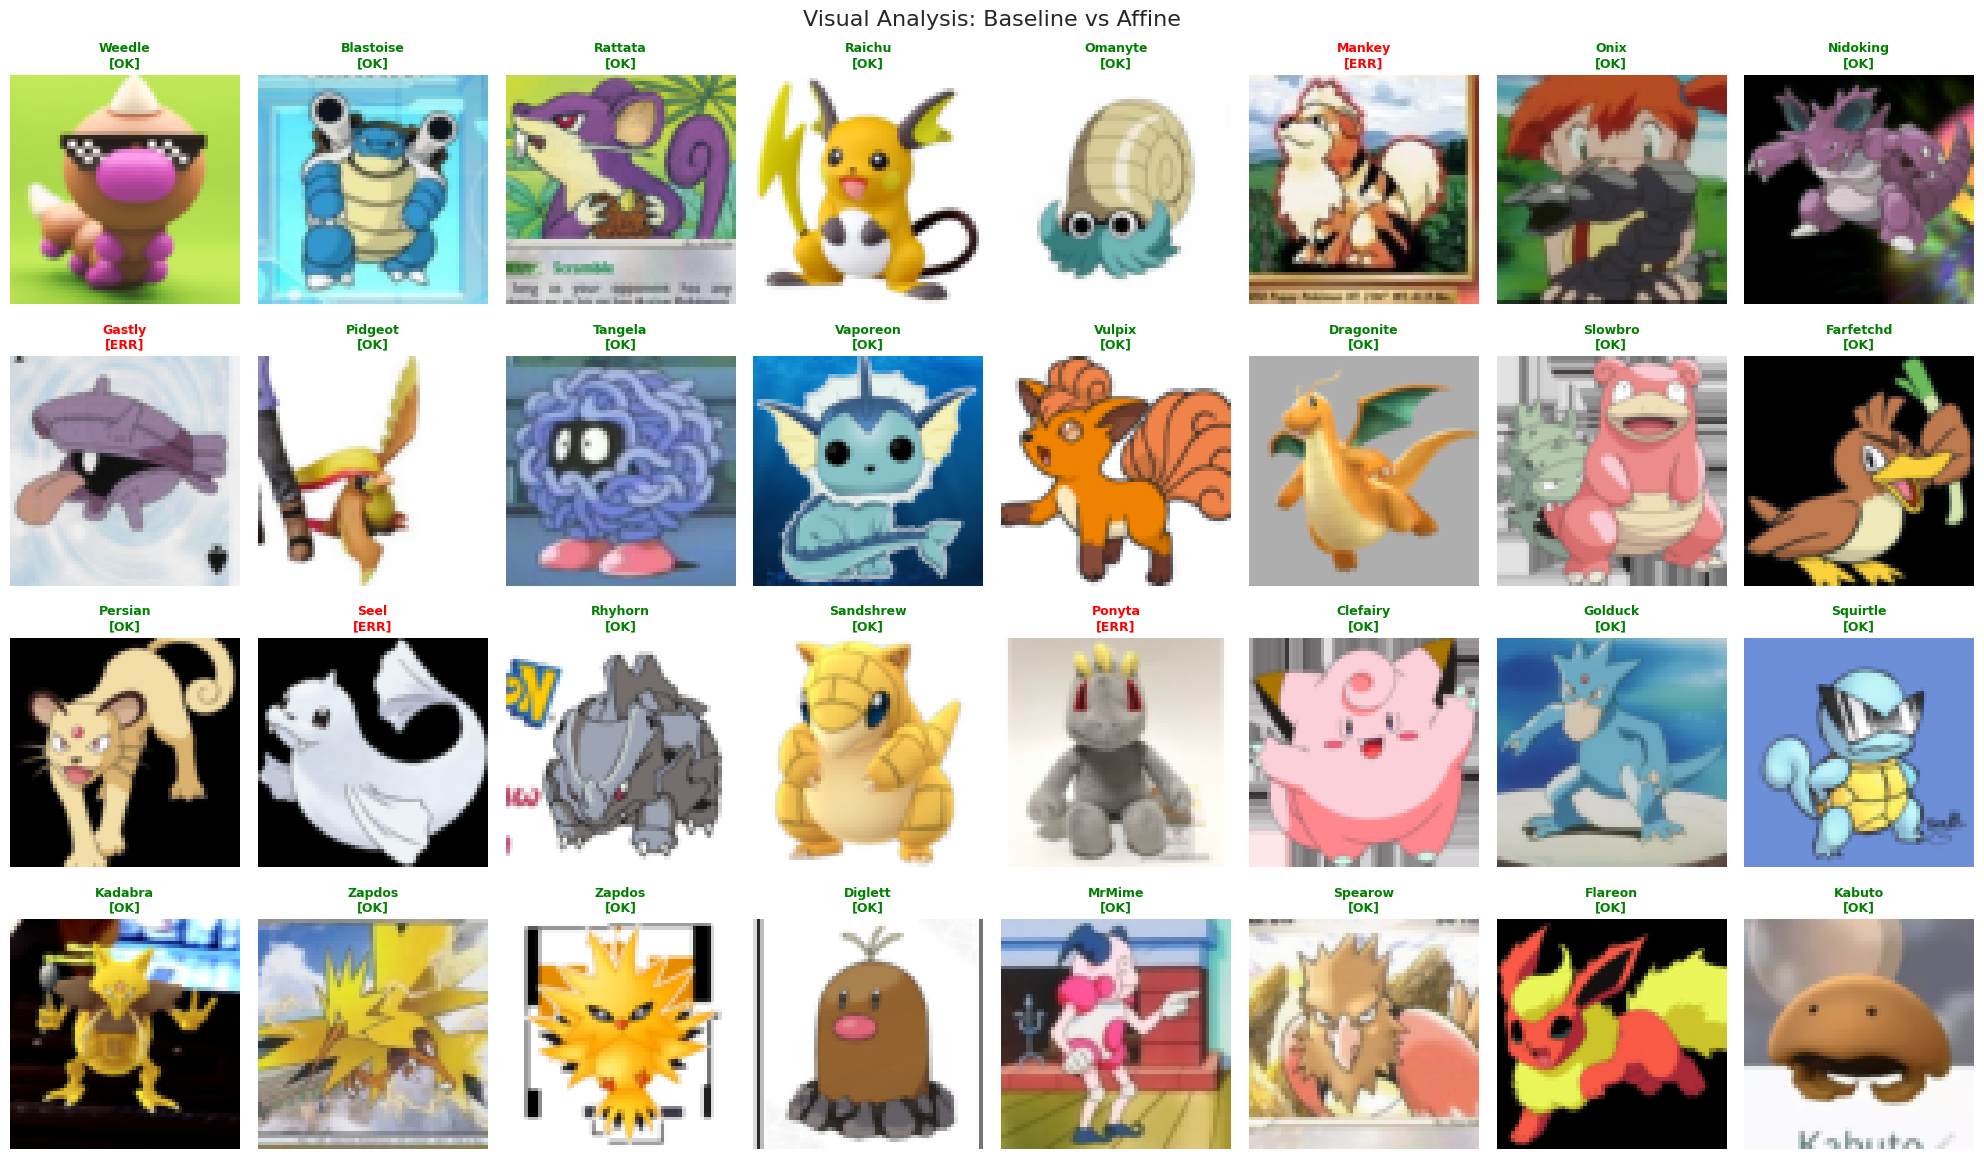


--- Confusion Matrix for Affine ---


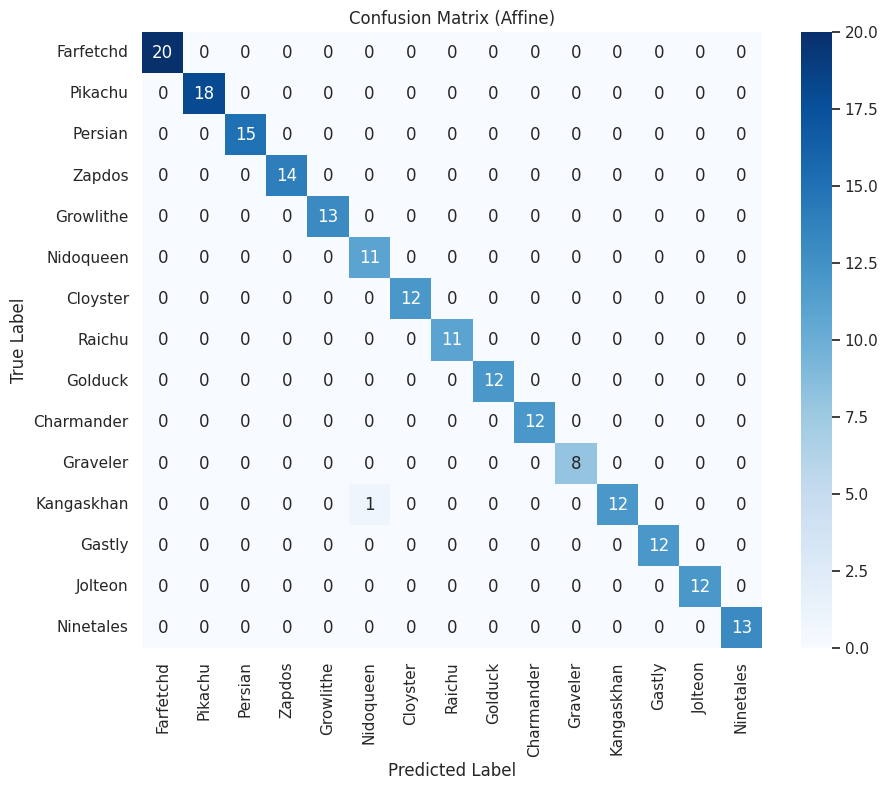

In [22]:
# --- 1. Load Data ---
print("--- Loading Datasets ---")
train_loader, test_loader, num_classes = get_data_loaders()

# Get class names safely
if hasattr(test_loader.dataset, 'classes'):
    class_names = test_loader.dataset.classes
elif hasattr(test_loader.dataset, 'dataset') and hasattr(test_loader.dataset.dataset, 'classes'):
    class_names = test_loader.dataset.dataset.classes
else:
    class_names = [str(i) for i in range(num_classes)]

# --- 2. Main Evaluation Loop ---
results_table = []
predictions_store = {}  # Store predictions for visualization
targets_store = {}      # Store targets for confusion matrix

print(f"\n--- Starting Scientific Evaluation of {len(MODELS_TO_EVALUATE)} Models ---")

for model_name in MODELS_TO_EVALUATE:
    # A. Load Model
    # Note: Ensure 'load_model' is defined from previous cells
    model = load_model(model_name, num_classes)
    if model is None:
        continue
    
    # B. Scientific Verification (Graph & Weights)
    # verify_quantization(model, model_name) # Checks graph structure keywords
    inspect_first_layer_weights(model, model_name) # Checks weights/scales/PoT status

    # C. Run Comprehensive Evaluation
    print(f"   Running Inference on {len(test_loader.dataset)} samples...")
    # Assumes 'evaluate_model_comprehensive' handles the inference loop and returns a dict
    metrics = evaluate_model_comprehensive(model, test_loader, EVAL_DEVICE)

    # D. Store Results
    res_entry = {
        "Model": model_name,
        "Accuracy": metrics["Accuracy"],
        "F1-Score": metrics["F1-Score"],
        "Precision": metrics["Precision"],
        "Recall": metrics["Recall"],
        "Latency (ms)": metrics["Latency (ms)"],
        "Throughput (img/s)": metrics["Throughput (img/s)"]
    }
    
    # Calculate Speedup vs Baseline (Assumes Baseline is run first)
    if results_table and results_table[0]["Model"] == "Baseline":
        base_lat = results_table[0]["Latency (ms)"]
        res_entry["Speedup (x)"] = base_lat / res_entry["Latency (ms)"]
    else:
        res_entry["Speedup (x)"] = 1.0
        
    results_table.append(res_entry)
    
    # Store raw predictions for plotting later
    predictions_store[model_name] = metrics["Predictions"]
    targets_store[model_name] = metrics["Targets"]
    
    print(f"   -> Result: Acc={metrics['Accuracy']:.2%} | Latency={metrics['Latency (ms)']:.2f} ms")

# --- 3. Final Scientific Results Table ---
print("\n" + "="*60)
print("             SCIENTIFIC EVALUATION RESULTS")
print("="*60)

df_results = pd.DataFrame(results_table)
if not df_results.empty:
    df_results = df_results.set_index("Model")
    pd.options.display.float_format = '{:,.4f}'.format
    display(df_results)
else:
    print("⚠️ No results found. Check model loading.")

# --- 4. Visualizations (Baseline vs. Best Quantized) ---
# We compare Baseline against 'Affine' (usually best) or the second model in the list
comp_model = "Affine" if "Affine" in predictions_store else (MODELS_TO_EVALUATE[1] if len(MODELS_TO_EVALUATE) > 1 else None)

if "Baseline" in predictions_store and comp_model:
    print(f"\n--- Visualizing Differences: Baseline vs {comp_model} ---")
    
    # 1. Get a batch of samples images
    # Assuming 'get_sample_images' helper exists
    sample_imgs, sample_targets = get_sample_images(test_loader, num=32)
    
    # 2. Get corresponding predictions for these 32 images
    # Note: Ideally, set test_loader shuffle=False to ensure indices match 
    # Or re-run inference on just this batch for visualization safety.
    preds_base = predictions_store["Baseline"][:32]
    preds_quant = predictions_store[comp_model][:32]
    
    # 3. Plot Grid Comparison
    plot_visual_comparison(
        sample_imgs, preds_base, preds_quant, sample_targets.numpy(),
        class_names, title=f"Visual Analysis: Baseline vs {comp_model}"
    )
    
    # 4. Plot Confusion Matrix for the Quantized Model
    print(f"\n--- Confusion Matrix for {comp_model} ---")
    plot_confusion_matrix(
        targets_store[comp_model], predictions_store[comp_model], 
        class_names, title=f"Confusion Matrix ({comp_model})"
    )


--- Visualizing Quantization Effects ---


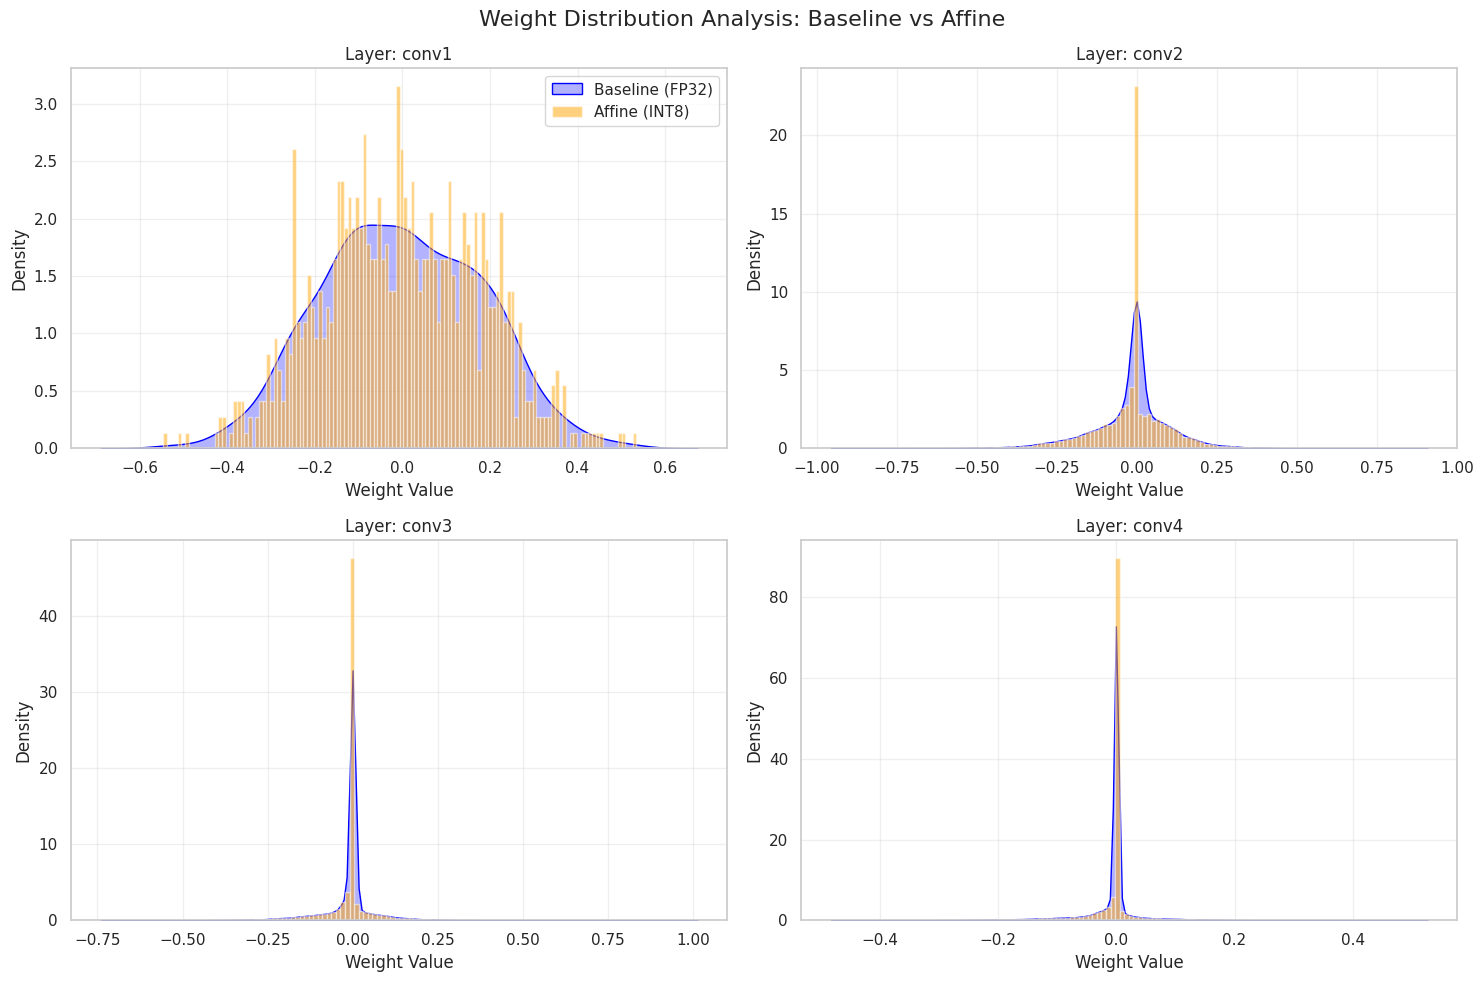

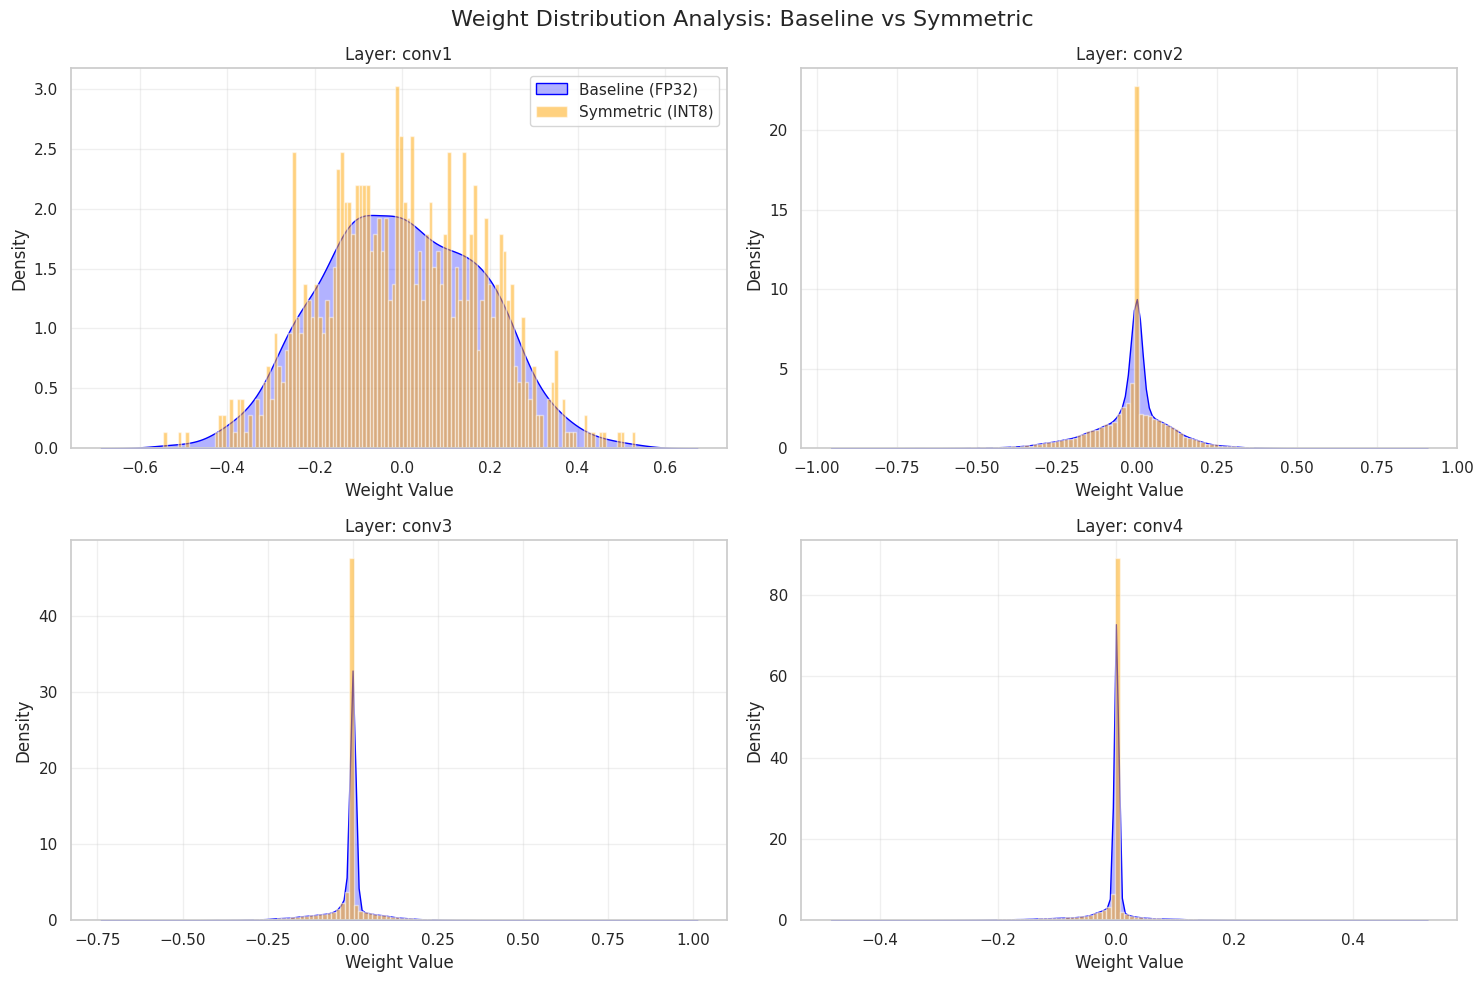

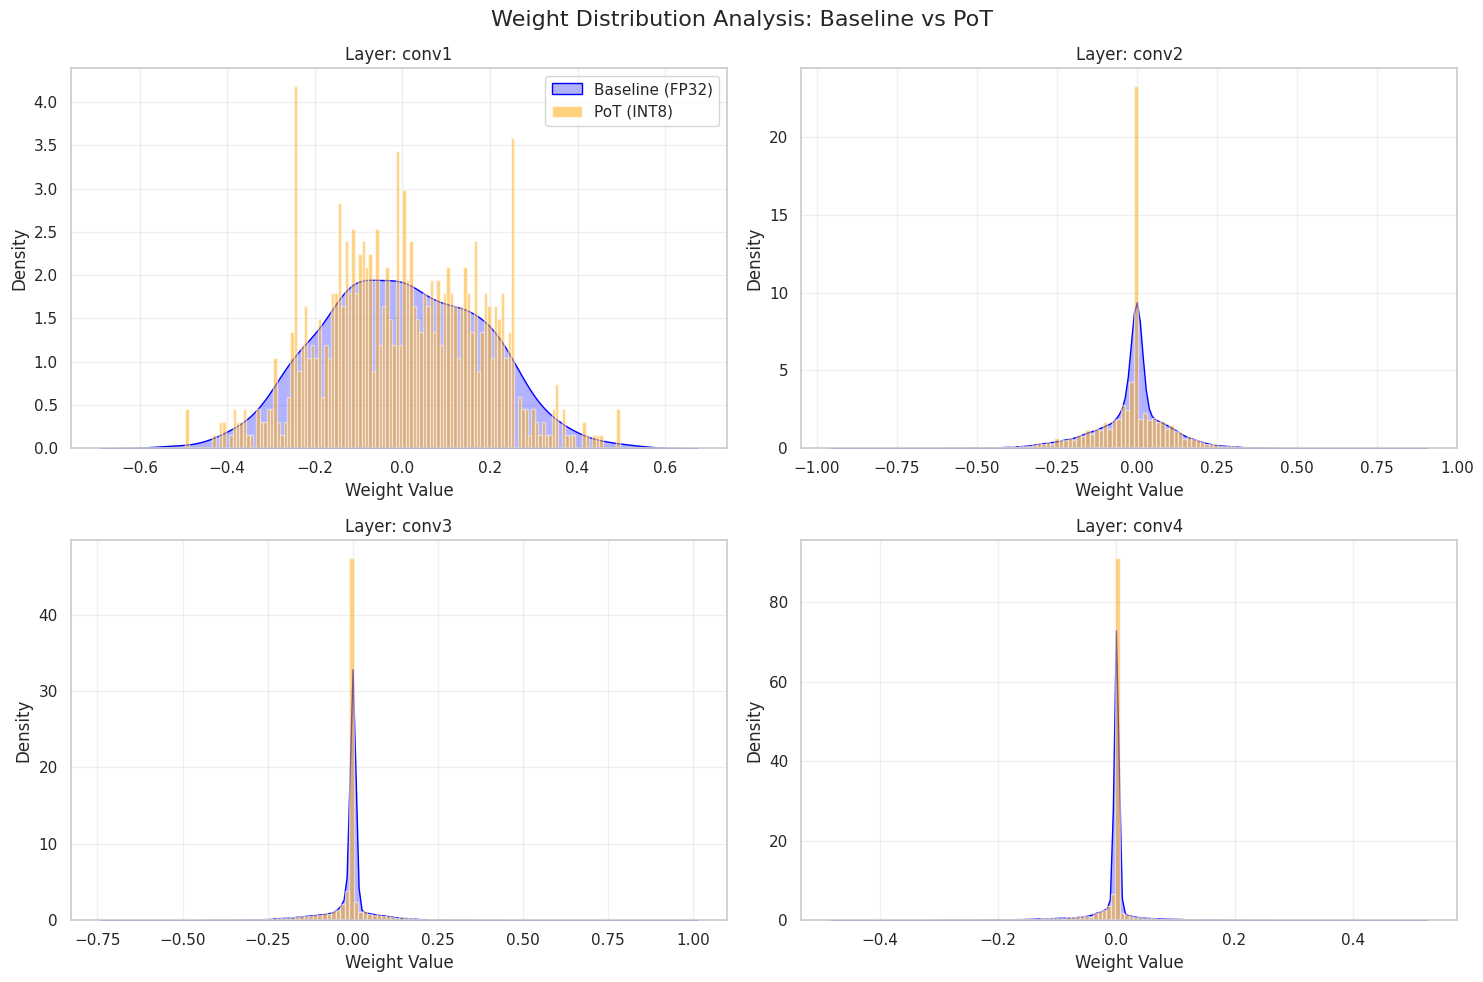

In [35]:
def plot_weight_histograms(baseline, quantized, quant_name):
    """
    Plots the continuous distribution of Baseline weights vs. 
    the discrete distribution of Quantized weights.
    """
    layers = ['conv1', 'conv2', 'conv3', 'conv4']

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"Weight Distribution Analysis: Baseline vs {quant_name}", fontsize=16)
    axes = axes.flatten()
    
    for i, layer_name in enumerate(layers):
        ax = axes[i]
        if not hasattr(baseline, layer_name) or not hasattr(quantized, layer_name):
            ax.text(0.5, 0.5, f"{layer_name} not found", ha='center')
            continue
        base_layer = getattr(baseline, layer_name)
        w_base = base_layer.weight.detach().cpu().numpy().flatten()
        
        quant_layer = getattr(quantized, layer_name)
        if hasattr(quant_layer, '_packed_params'):
            w_quant_packed = quant_layer._packed_params.unpack()[0]
            w_quant = w_quant_packed.dequantize().detach().cpu().numpy().flatten()
        else:
            ax.text(0.5, 0.5, "Not quantized/packed", ha='center')
            continue
    
        # Baseline: Smooth curve (KDE)
        sns.kdeplot(w_base, color='blue', fill=True, label='Baseline (FP32)', alpha=0.3, ax=ax)
        
        # Quantized: Discrete bins (Histogram)
        # We increase bins to 128 to show the discrete steps clearly
        ax.hist(w_quant, bins=128, color='orange', alpha=0.5, label=f'{quant_name} (INT8)', density=True)
        
        ax.set_title(f"Layer: {layer_name}")
        ax.set_xlabel("Weight Value")
        ax.set_ylabel("Density")
        if i == 0: # Only show legend on first plot to save space
            ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run Visualization (Compare Baseline vs Affine)
print("\n--- Visualizing Quantization Effects ---")
    
model_base = load_model("Baseline", num_classes)
model_aff = load_model("Affine", num_classes)

if model_base and model_aff:
    plot_weight_histograms(model_base, model_aff, "Affine")

model_sym = load_model("Symmetric", num_classes)

if model_base and model_sym:
    plot_weight_histograms(model_base, model_sym, "Symmetric")

model_pot = load_model("PoT", num_classes)

if model_base and model_pot:
    plot_weight_histograms(model_base, model_pot, "PoT")